In [1]:
# Basics
import pandas as pd
import numpy as np
import pickle

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns
from model_evaluation import *

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model support
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, auc, plot_confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve)

In [2]:
raw_dataframe = pd.read_csv("twitter_dataset_expanded.csv")
raw_dataframe['bot'] = raw_dataframe['bot_status'].apply(lambda x: 1 if x == 'bot' else 0)
raw_dataframe['default_profile_image'] = raw_dataframe['profile_image_url'].apply(lambda x: 1 if x == 'https://abs.twimg.com/sticky/default_profile_images/default_profile_normal.png' else 0)
raw_dataframe['verified'] = raw_dataframe['verified'].apply(lambda x: 1 if x == 'True' else 0)

raw_dataframe['created_at'] = pd.to_datetime(raw_dataframe['created_at'])
raw_dataframe['hour_created'] = pd.to_datetime(raw_dataframe['created_at']).dt.hour

In [3]:
dataframe = raw_dataframe[['id', 'bot', 'created_at', 'account_age_days', 'verified', 'hour_created', 'default_profile_image', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'average_tweets_per_day']]

In [4]:
del raw_dataframe

In [5]:
# Interesting features to look at: 
dataframe['avg_daily_followers'] = np.round((dataframe['followers_count'] / dataframe['account_age_days']), 3)
dataframe['avg_daily_following'] = np.round((dataframe['following_count'] / dataframe['account_age_days']), 3)
dataframe['avg_daily_listed'] = np.round((dataframe['listed_count'] / dataframe['account_age_days']), 3)

# Log transformations for highly skewed data
dataframe['following_log'] = np.round(np.log(1 + dataframe['following_count']), 3)
dataframe['followers_log'] = np.round(np.log(1 + dataframe['followers_count']), 3)
dataframe['listed_log'] = np.round(np.log(1 + dataframe['listed_count']), 3)
dataframe['avg_daily_tweets_log'] = np.round(np.log(1+ dataframe['average_tweets_per_day']), 3)

# Possible interactive features
dataframe['network'] = np.round(dataframe['following_log'] * dataframe['followers_log'], 3)
dataframe['tweet_to_followers'] = np.round(np.log( 1 + dataframe['tweet_count']) * np.log(1+ dataframe['followers_count']), 3)

# Log-transformed daily acquisition metrics for dist. plots
dataframe['follower_acq_rate'] = np.round(np.log(1 + (dataframe['followers_count'] / dataframe['account_age_days'])), 3)
dataframe['following_acq_rate'] = np.round(np.log(1 + (dataframe['following_count'] / dataframe['account_age_days'])), 3)
dataframe['listed_acq_rate'] = np.round(np.log(1 + (dataframe['listed_count'] / dataframe['account_age_days'])), 3)

In [6]:
dataframe.head()

,id,bot,created_at,account_age_days,verified,hour_created,default_profile_image,followers_count,following_count,tweet_count,...,avg_daily_listed,following_log,followers_log,listed_log,avg_daily_tweets_log,network,tweet_to_followers,follower_acq_rate,following_acq_rate,listed_acq_rate
0,787405734442958848,1,2016-10-15 21:32:11+00:00,2057,0,21,0,1947,5,16084,...,0.027,1.792,7.575,4.043,2.177,13.574,73.364,0.666,0.002,0.027
1,796216118331310080,0,2016-11-09 05:01:30+00:00,2033,0,5,0,798,836,251,...,0.002,6.730,6.683,1.792,0.116,44.977,36.955,0.331,0.344,0.002
2,875949740503859204,0,2017-06-17 05:34:27+00:00,1813,0,5,0,204,1039,1343,...,0.001,6.947,5.323,1.099,0.554,36.979,38.344,0.107,0.453,0.001
3,756119643622735875,0,2016-07-21 13:32:25+00:00,2144,0,13,0,727,826,2321,...,0.001,6.718,6.590,1.099,0.734,44.272,51.076,0.292,0.326,0.001
4,464781334,0,2012-01-15 16:32:35+00:00,3793,0,16,0,738946,126,4635,...,0.470,4.844,13.513,7.485,0.798,65.457,114.071,5.277,0.033,0.385


In [7]:
features = ['verified', 
            #'created_at',
            #'hour_created',
            'default_profile_image', 
            'listed_count', 
            'followers_count', 
            'following_count', 
            'tweet_count', 
            'average_tweets_per_day',
            #'avg_daily_followers', 
            #'avg_daily_friends',
            #'avg_daily_favorites',
            'network', 
            'tweet_to_followers', 
            'follower_acq_rate', 
            'following_acq_rate', 
            'listed_acq_rate'
           ]

X = dataframe[features]
y = dataframe['bot']

In [8]:
X, X_test, y, y_test = train_test_split(X, y, test_size=.3, random_state=1234)

In [9]:
# Models that require scaling: 
knn = KNeighborsClassifier(n_neighbors=10)
lr = LogisticRegression()

# Scaling
scalar = StandardScaler()
scalar.fit(X)
X_train_scaled = scalar.transform(X)

model_list = [knn, lr]
kf = KFold(n_splits=5, shuffle=True, random_state=33)

In [10]:
multi_model_eval(model_list, X_train_scaled, y, kf)

Model: KNeighborsClassifier(n_neighbors=10)
------------------------------
Accuracy:  0.82593 +- 0.002321
Precision: 0.78862 +- 0.007976
Recall:    0.64540 +- 0.009056
F1 Score:  0.70981 +- 0.006444
ROC AUC:   0.86782 +- 0.005225

Model: LogisticRegression()
------------------------------
Accuracy:  0.80212 +- 0.003441
Precision: 0.71470 +- 0.006986
Recall:    0.66602 +- 0.010901
F1 Score:  0.68947 +- 0.008043
ROC AUC:   0.84059 +- 0.006635



In [11]:
# Models that don't require scaling
gnb = GaussianNB()
bnb = BernoulliNB()
mnb = MultinomialNB()
tree = DecisionTreeClassifier()
forest = RandomForestClassifier()
xgb = XGBClassifier()

model_list = [gnb, bnb, mnb, tree, forest, xgb]
kf = KFold(n_splits=3, shuffle=True, random_state=33)

In [12]:
multi_model_eval(model_list, X, y, kf)

Model: GaussianNB()
------------------------------
Accuracy:  0.47771 +- 0.129102
Precision: 0.35966 +- 0.016282
Recall:    0.67550 +- 0.448385
F1 Score:  0.36877 +- 0.207978
ROC AUC:   0.80508 +- 0.009480

Model: BernoulliNB()
------------------------------
Accuracy:  0.74820 +- 0.002998
Precision: 0.69491 +- 0.005162
Recall:    0.42214 +- 0.012504
F1 Score:  0.52515 +- 0.010906
ROC AUC:   0.75138 +- 0.008920

Model: MultinomialNB()
------------------------------
Accuracy:  0.47242 +- 0.005436
Precision: 0.38317 +- 0.002851
Recall:    0.98189 +- 0.000833
F1 Score:  0.55123 +- 0.003080
ROC AUC:   0.59430 +- 0.004574

Model: DecisionTreeClassifier()
------------------------------
Accuracy:  0.77755 +- 0.002119
Precision: 0.65995 +- 0.006238
Recall:    0.67255 +- 0.010612
F1 Score:  0.66610 +- 0.004383
ROC AUC:   0.75132 +- 0.002535

Model: RandomForestClassifier()
------------------------------
Accuracy:  0.83728 +- 0.002728
Precision: 0.79802 +- 0.005183
Recall:    0.67859 +- 0.007710


Average AUC Score: 0.8895 +- 0.003997


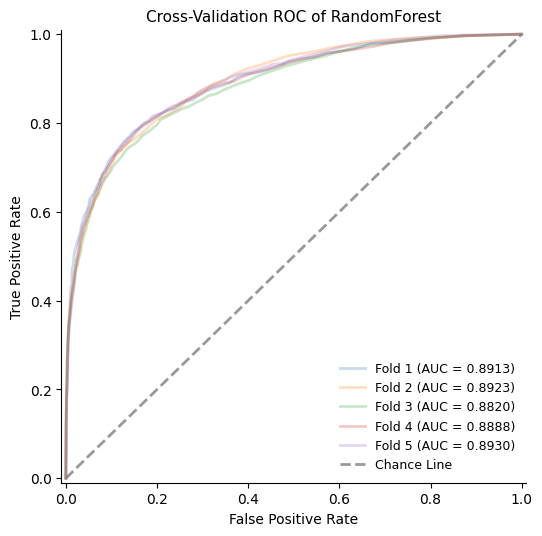

In [13]:
forest = RandomForestClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=33)

roc_curve_cv(forest, X, y, kf, model_alias='RandomForest')

Average Precision Score: 0.8006 +- 0.006775
Average Recall Score: 0.6798 +- 0.006387


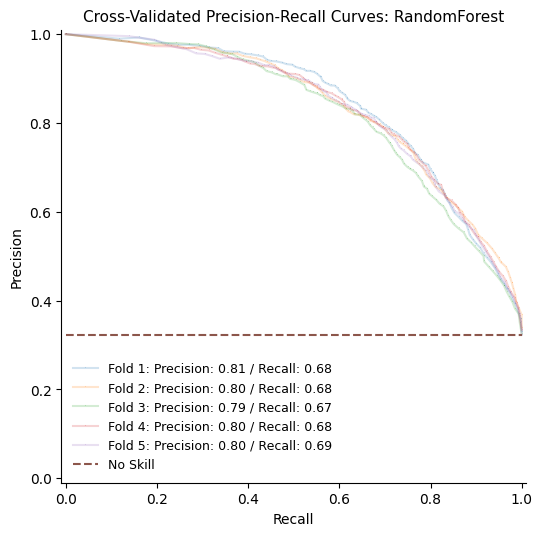

In [14]:
precision_recall_cv(forest, X, y, kf, model_alias='RandomForest')

Average AUC Score: 0.8889 +- 0.005319


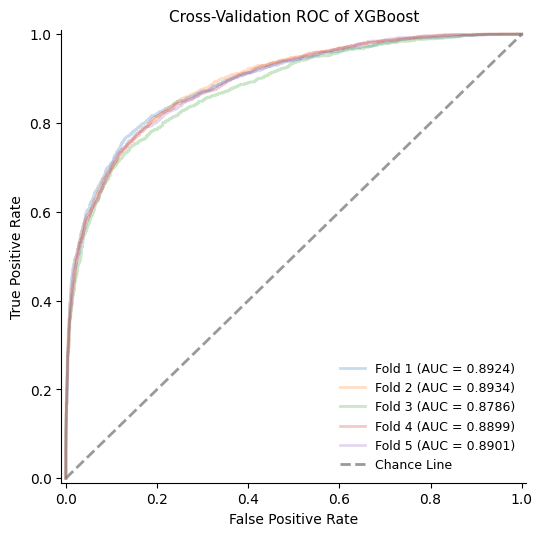

In [15]:
xgb = XGBClassifier()

kf = KFold(n_splits=5, shuffle=True, random_state=33)

roc_curve_cv(xgb, X, y, kf, model_alias='XGBoost')

Average Precision Score: 0.7899 +- 0.008538
Average Recall Score: 0.6791 +- 0.005465


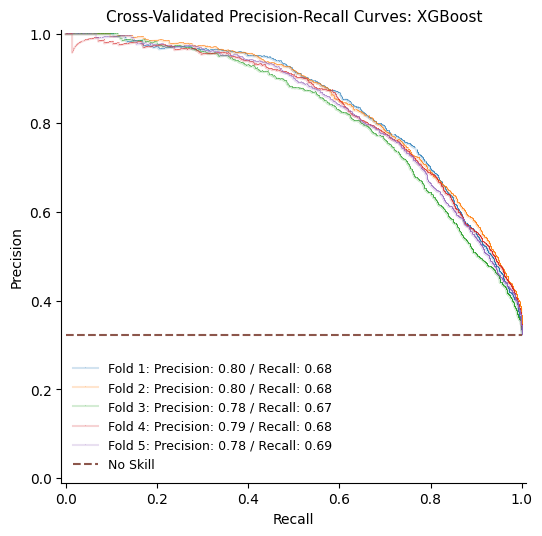

In [16]:
precision_recall_cv(xgb, X, y, kf, model_alias='XGBoost')

In [17]:
num_bots = len(dataframe[dataframe['bot'] == 1])
num_humans = len(dataframe[dataframe['bot'] == 0])

print("Number of bots: ", num_bots)
print("Number of humans: ", num_humans)
print(f'Bots / Total %: {(num_bots / len(dataframe))*100:.2f}')

Number of bots:  11923
Number of humans:  23951
Bots / Total %: 33.24


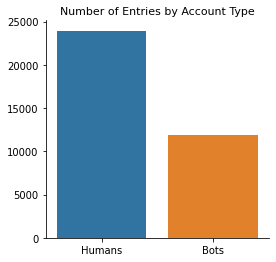

In [18]:
types = ['Humans', 'Bots']
counts = [num_humans, num_bots]

plt.figure(figsize=(4, 4))
sns.barplot(x = types, y = counts)
plt.title("Number of Entries by Account Type", fontsize=11)
sns.despine()

In [19]:
# For XGBoost
estimate = num_humans/num_bots
estimate

2.0088065084290867

In [20]:
forest = RandomForestClassifier(class_weight='balanced')
xgb = XGBClassifier(scale_pos_weight=estimate)

models = [forest, xgb]
kf = KFold(n_splits=5, shuffle=True, random_state=33)

In [21]:
multi_model_eval(models, X, y, kf)

Model: RandomForestClassifier(class_weight='balanced')
------------------------------
Accuracy:  0.83828 +- 0.003836
Precision: 0.80299 +- 0.005653
Recall:    0.67558 +- 0.006943
F1 Score:  0.73379 +- 0.006227
ROC AUC:   0.88904 +- 0.003243

Model: XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)
------------------------------
Accuracy:  0.82283 +-

Average AUC Score: 0.8884 +- 0.004400


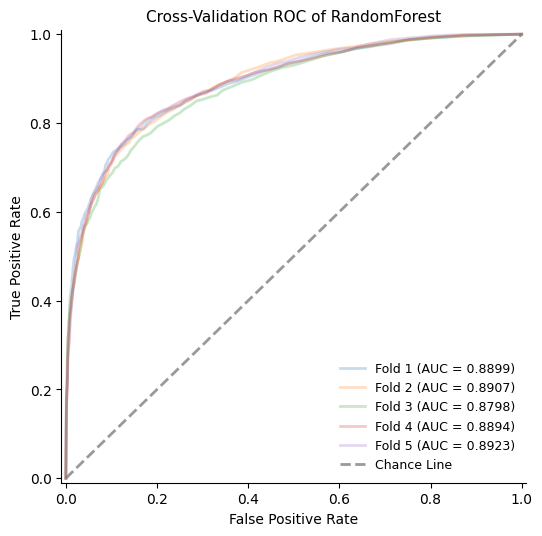

In [22]:
roc_curve_cv(forest, X, y, kf, model_alias='RandomForest')

Average Precision Score: 0.8067 +- 0.007486
Average Recall Score: 0.6720 +- 0.006285


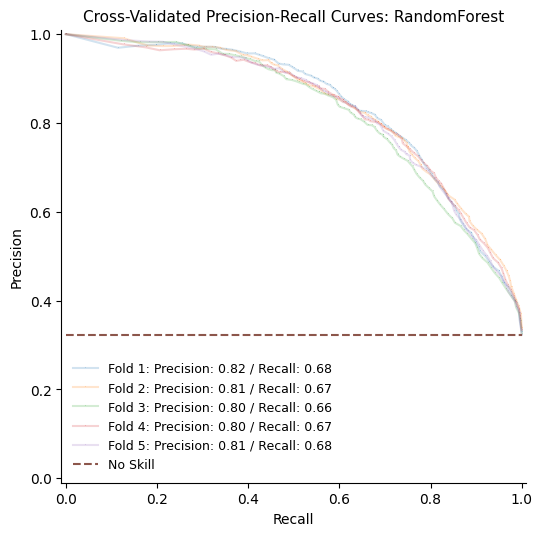

In [23]:
precision_recall_cv(forest, X, y, kf, model_alias='RandomForest')

Average AUC Score: 0.8882 +- 0.005346


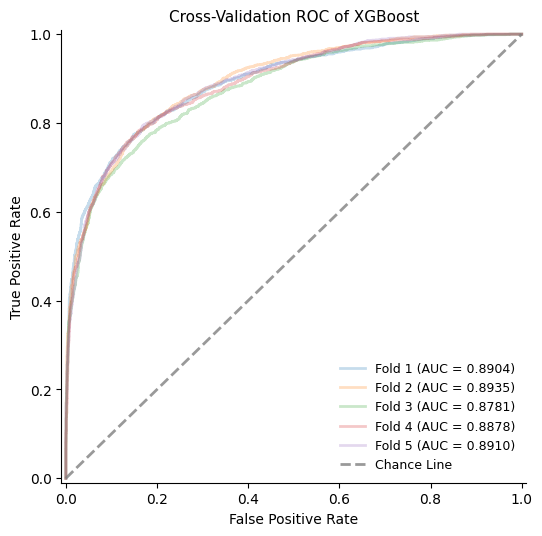

In [24]:
roc_curve_cv(xgb, X, y, kf, model_alias='XGBoost')

Average Precision Score: 0.7198 +- 0.013282
Average Recall Score: 0.7581 +- 0.011363


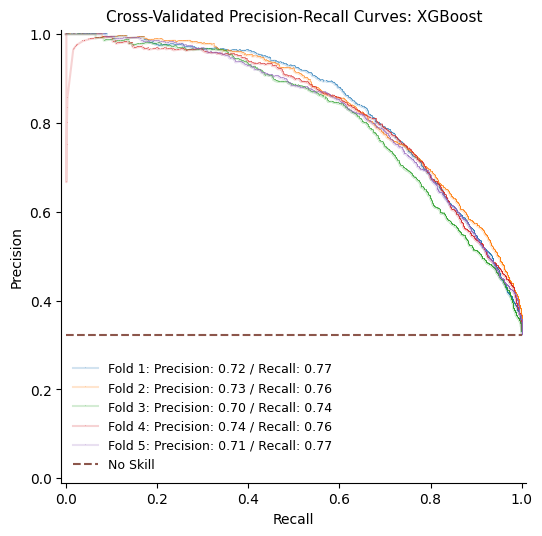

In [25]:
precision_recall_cv(xgb, X, y, kf, model_alias='XGBoost')

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.25, random_state=3333)

In [27]:
forest = RandomForestClassifier(class_weight='balanced')

forest.fit(X_train, y_train)
preds = forest.predict(X_val)

Classification Metrics Report
-----------------------------
Accuracy:  0.8445
Precision: 0.8005
Recall:    0.6926
F1 Score:  0.7426

              precision    recall  f1-score   support

           0       0.86      0.92      0.89      4245
           1       0.80      0.69      0.74      2033

    accuracy                           0.84      6278
   macro avg       0.83      0.80      0.82      6278
weighted avg       0.84      0.84      0.84      6278




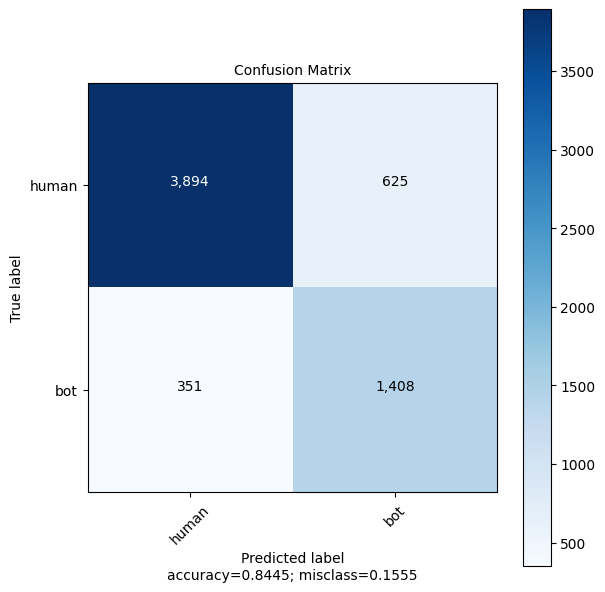

In [28]:
metrics_report(preds, y_val)

In [29]:
xgb = XGBClassifier(scale_pos_weight=estimate)

xgb.fit(X_train, y_train)
preds = xgb.predict(X_val)

Classification Metrics Report
-----------------------------
Accuracy:  0.8267
Precision: 0.7131
Recall:    0.7777
F1 Score:  0.7440

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      4245
           1       0.71      0.78      0.74      2033

    accuracy                           0.83      6278
   macro avg       0.80      0.81      0.81      6278
weighted avg       0.83      0.83      0.83      6278




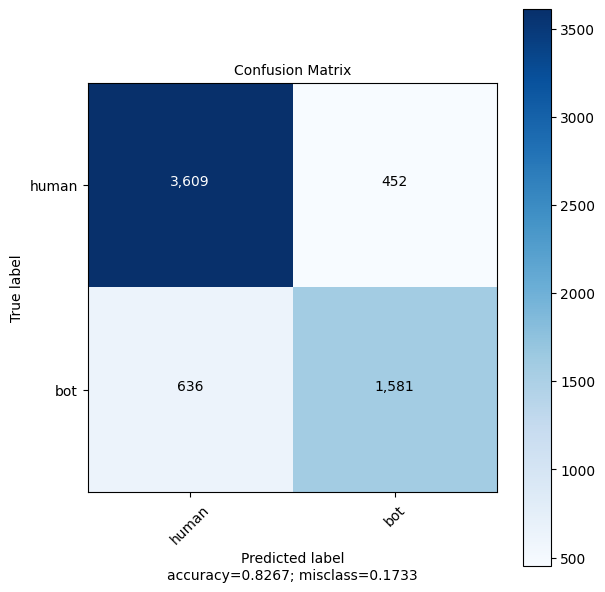

In [30]:
metrics_report(preds, y_val)

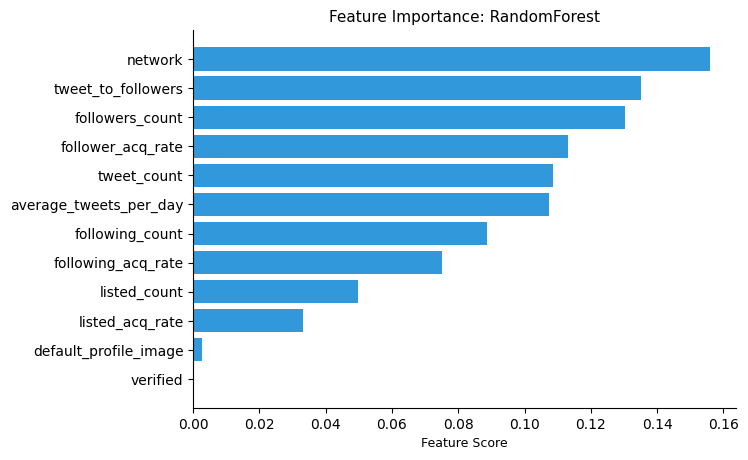

In [31]:
plot_feature_importance(forest, features, model_alias='RandomForest')

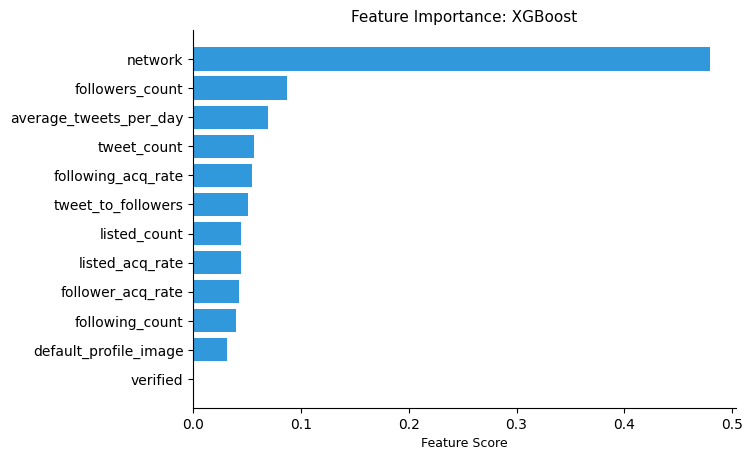

In [32]:
plot_feature_importance(xgb, features, model_alias='XGBoost')

In [33]:
dataframe.head(3)

,id,bot,created_at,account_age_days,verified,hour_created,default_profile_image,followers_count,following_count,tweet_count,...,avg_daily_listed,following_log,followers_log,listed_log,avg_daily_tweets_log,network,tweet_to_followers,follower_acq_rate,following_acq_rate,listed_acq_rate
0,787405734442958848,1,2016-10-15 21:32:11+00:00,2057,0,21,0,1947,5,16084,...,0.027,1.792,7.575,4.043,2.177,13.574,73.364,0.666,0.002,0.027
1,796216118331310080,0,2016-11-09 05:01:30+00:00,2033,0,5,0,798,836,251,...,0.002,6.730,6.683,1.792,0.116,44.977,36.955,0.331,0.344,0.002
2,875949740503859204,0,2017-06-17 05:34:27+00:00,1813,0,5,0,204,1039,1343,...,0.001,6.947,5.323,1.099,0.554,36.979,38.344,0.107,0.453,0.001


In [34]:
features = ['verified', 
            #'created_at',
            'hour_created',
            'default_profile_image', 
            'listed_count',
            'followers_count', 
            'following_count',
            'tweet_count', 
            'average_tweets_per_day',
            #'avg_daily_followers', 
            #'avg_daily_friends',
            #'avg_daily_favorites',
            'network', 
            'tweet_to_followers', 
            'follower_acq_rate', 
            'following_acq_rate', 
            #'listed_acq_rate'
           ]

X = dataframe[features]
y = dataframe['bot']

X, X_test, y, y_test = train_test_split(X, y, test_size=.3, random_state=1234)

In [35]:
xgb = XGBClassifier(scale_pos_weight=1.8, 
                    tree_method='hist', 
                    learning_rate=0.1,           
                    eta=0.01,                 
                    max_depth=7,                
                    gamma=0.05,
                    n_estimators=200,
                    colsample_bytree=.8
                   )

model_list = [xgb]

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=33)

multi_model_eval(model_list, X, y, kf)

Model: XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False, eta=0.01,
              eval_metric=None, gamma=0.05, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=7, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, ...)
------------------------------
Accuracy:  0.83043 +- 0.004953
Precision: 0.74098 +- 0.011414
Recall:    0.74709 +- 0.009016
F1 Score:  0.74401 +- 0.009718
ROC AUC:   0.89334 +- 0.004072



Average AUC Score: 0.8933 +- 0.004072


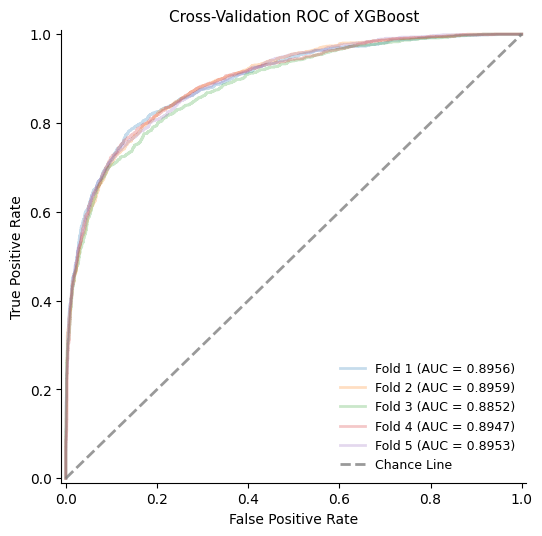

In [37]:
roc_curve_cv(xgb, X, y, kf, model_alias='XGBoost')

Average Precision Score: 0.7410 +- 0.011414
Average Recall Score: 0.7471 +- 0.009016


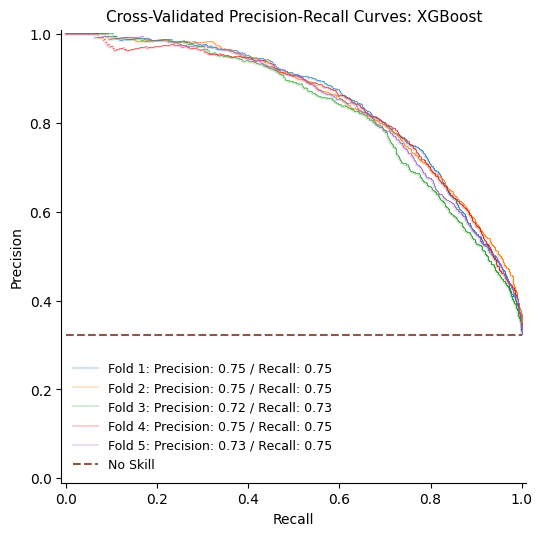

In [38]:
precision_recall_cv(xgb, X, y, kf, model_alias='XGBoost')

In [39]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.3, random_state=1234)

In [40]:
forest = RandomForestClassifier(class_weight='balanced')
forest = forest.fit(X_train, y_train)

xgb = XGBClassifier(scale_pos_weight=1.8, 
                    tree_method='hist', 
                    learning_rate=0.1,           
                    eta=0.01,                 
                    max_depth=7,                
                    gamma=0.05,
                    n_estimators=200,
                    colsample_bytree=.8
                   )

xgb = xgb.fit(X_train, y_train)

In [41]:
models = [('forest', forest), ('xgb', xgb)]

voting_classifier = VotingClassifier(estimators=models,
                                     voting='soft',
                                     n_jobs=-1)

voting_classifier = voting_classifier.fit(X_train, y_train)

Classification Metrics Report
-----------------------------
Accuracy:  0.8369
Precision: 0.7815
Recall:    0.7076
F1 Score:  0.7427

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      5027
           1       0.78      0.71      0.74      2507

    accuracy                           0.84      7534
   macro avg       0.82      0.80      0.81      7534
weighted avg       0.83      0.84      0.83      7534




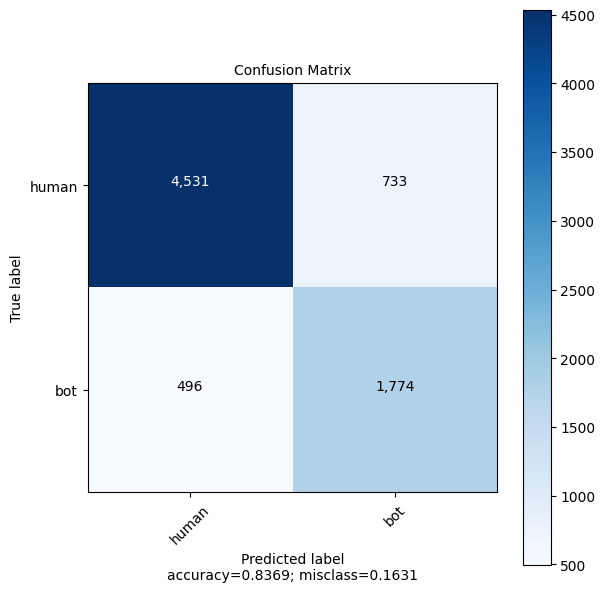

In [42]:
voting_classifier_prediction = voting_classifier.predict(X_val)

metrics_report(voting_classifier_prediction, y_val)

In [43]:
# Full train & test
best_model = XGBClassifier(scale_pos_weight=1.8, 
                    tree_method='hist', 
                    learning_rate=0.1,           
                    eta=0.01,                 
                    max_depth=7,                
                    gamma=0.05,
                    n_estimators=200,
                    colsample_bytree=.8
                   )

In [44]:
best_model.fit(X, y)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False, eta=0.01,
              eval_metric=None, gamma=0.05, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=7, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, ...)

Classification Metrics Report
-----------------------------
Accuracy:  0.8270
Precision: 0.7416
Recall:    0.7490
F1 Score:  0.7453

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      7126
           1       0.74      0.75      0.75      3637

    accuracy                           0.83     10763
   macro avg       0.81      0.81      0.81     10763
weighted avg       0.83      0.83      0.83     10763




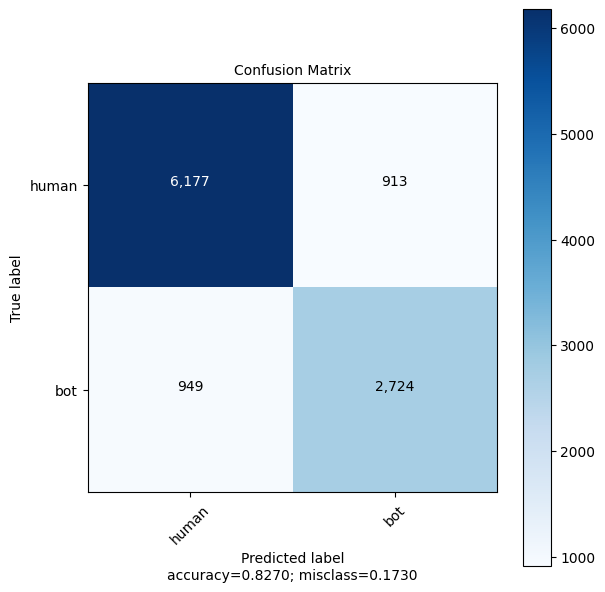

In [45]:
best_model_prediction = best_model.predict(X_test)

metrics_report(best_model_prediction, y_test)

ROC AUC score: 0.8929



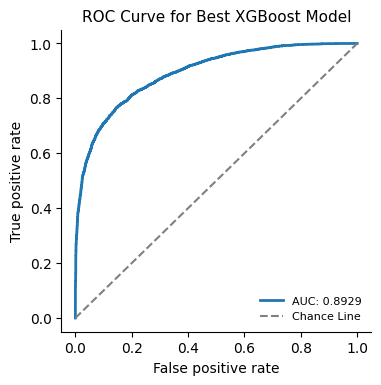

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test)[:,1])

model_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(4, 4), dpi=100)
plt.plot(fpr, tpr,lw=2, label=f'AUC: {model_auc:.4f}')
plt.plot([0,1],[0,1],c='grey',ls='--', label='Chance Line')
plt.xlim([-0.05,1.05])
plt.ylim([-0.05,1.05])

plt.xlabel('False positive rate', fontsize=10)
plt.ylabel('True positive rate', fontsize=10)
plt.title('ROC Curve for Best XGBoost Model', fontsize=11)
plt.legend(loc='lower right', prop={'size': 8}, frameon=False)
sns.despine()
print(f'ROC AUC score: {model_auc:.4f}')
print("")
plt.show()

Precision score: 0.7416
Rcall score: 0.7490



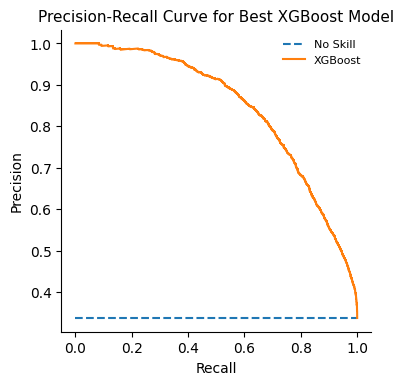

In [47]:
# Prec Recal Curve here

model_precision, model_recall, _ = precision_recall_curve(y_test, best_model.predict_proba(X_test)[:,1])

# plot the precision-recall curves
no_skill = len(y_test[y_test==1]) / len(y_test)

plt.figure(figsize=(4, 4), dpi=100)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(model_recall, model_precision, marker=',', label='XGBoost')
# axis labels
plt.title('Precision-Recall Curve for Best XGBoost Model', fontsize=11)
plt.xlabel('Recall', fontsize=10)
plt.ylabel('Precision', fontsize=10)
# show the legend
plt.legend(loc='upper right', prop={'size': 8}, frameon=False)
# show the plot
sns.despine()

pred = best_model.predict(X_test)
prec_score = precision_score(y_test, pred)
rec_score = recall_score(y_test, pred)

print(f'Precision score: {prec_score:.4f}')
print(f'Rcall score: {rec_score:.4f}')
print("")

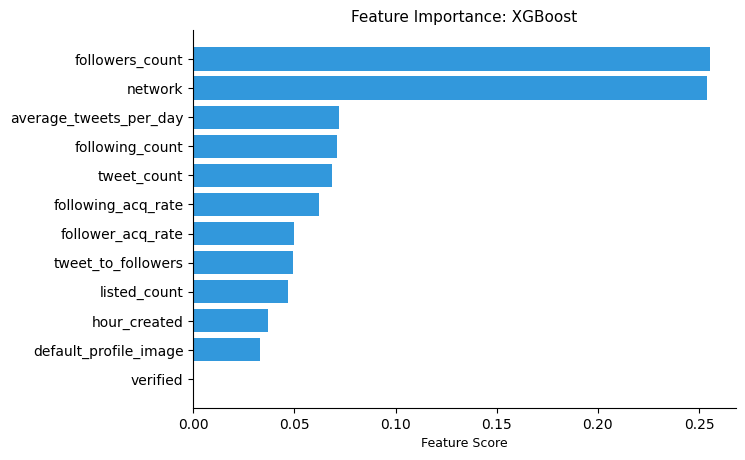

In [48]:
plot_feature_importance(best_model, features, model_alias='XGBoost')

In [49]:
features = ['verified', 
            'hour_created',
            'default_profile_image', 
            'listed_count', 
            'followers_count', 
            'following_count', 
            'tweet_count', 
            'average_tweets_per_day',
            'network', 
            'tweet_to_followers', 
            'follower_acq_rate', 
            'following_acq_rate', 
            'listed_acq_rate'
           ]

X = dataframe[features]
y = dataframe['bot']

In [50]:
fully_trained_model = XGBClassifier(scale_pos_weight=1.8, 
                                    tree_method='hist', 
                                    learning_rate=0.1,           
                                    eta=0.01,                 
                                    max_depth=7,                
                                    gamma=0.05,
                                    n_estimators=200,
                                    colsample_bytree=.8
                                   )

fully_trained_model.fit(X, y)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False, eta=0.01,
              eval_metric=None, gamma=0.05, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=7, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=200,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, ...)

In [51]:
with open('model.pickle', 'wb') as to_write:
    pickle.dump(fully_trained_model, to_write)